# WhyWatt — Rate Check for a ZIP  (advocate tool)

**Purpose:** before running the simulator for a household, check what rate WhyWatt will use for its ZIP — and *why*. Enter a ZIP (e.g. Palo Alto `94301`), read the plain-English verdict, and see the actual rates. Some ZIPs won't have utility-specific data; this shows exactly what the simulation falls back to.

Run on the **WhyWatt (venv)** kernel. Electric rates from URDB; gas from EIA.


In [1]:
import json, calendar, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False})
ROOT = Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src')); sys.path.insert(0, str(ROOT/'scripts'))
DB = json.loads((ROOT/'data/rates/urdb_tou.json').read_text())['utilities']
EIA = json.loads((ROOT/'data/rates/eia_rates_by_utility.json').read_text())
from rate_resolver import RateResolver
import urdb_coverage as COV, urdb_baseline as BL
RR = RateResolver()
MONTHS=[calendar.month_abbr[m+1] for m in range(12)]
def default(u): return u['tariffs'][u['default_label']]
# raw schedules (all utilities) for the peak-hour heatmap
_RAW={}
for p in (ROOT/'data/rates/sources/urdb').glob('*_flagship_raw.json'):
    for r in json.loads(p.read_text())['records']: _RAW[r['label']]=r
print('harvested utilities:', [DB[u]['utility'] for u in DB], '| coverage-maintained:', len(COV.maintained_ids()))


harvested utilities: ['Pacific Gas & Electric', 'Southern California Edison', 'San Diego Gas & Electric'] | coverage-maintained: 114


## 1. Enter a ZIP — what will the simulation do?
The headline check. It shows the resolved utility, whether real URDB rates apply, the baseline climate territory, the gas provider, and a one-line **fidelity verdict**.


In [2]:
def diagnose(zipcode='94301'):
    z=str(zipcode).strip(); res=RR.resolve(z); e=res.electricity; g=res.gas; eid=e.utility_id
    print('='*72)
    print(f'  ZIP {z}')
    print('='*72)
    # --- electric utility resolution ---
    prov_txt={'matched':'exact ZIP match','inferred':'INFERRED from ZIP prefix (approximate)',
              'fallback':'no match -> CA statewide average','selected':'CA average (chosen)'}
    print(f"Electric utility : {e.name}" + (f' (EIA {eid})' if eid else ''))
    print(f"                   {prov_txt.get(e.provenance, e.provenance)}")
    dec = COV.decide(eid)
    # --- what rate will be used + why ---
    if dec=='urdb':
        u=DB[str(eid)]; d=default(u); bl=BL.baseline_for_zip(eid, z)
        print(f"\nRATE USED       : URDB {d['family']}  (the default; {len(u['tariffs'])} plans available)")
        print(f"                   real time-of-use rates, effective ~${d['effective_level']}/kWh")
        if bl.source=='mapped':
            print(f"Baseline zone   : {bl.region} (from climate zone {bl.cec_zone}, {bl.confidence}) "
                  f"-> {bl.summer_kwh_day}/{bl.winter_kwh_day} kWh/day summer/winter")
        elif bl.source=='representative':
            print(f"Baseline zone   : {bl.region} (climate zone {bl.cec_zone} unmapped -> representative)")
        elif bl.source=='flat_no_baseline':
            print(f"Baseline zone   : n/a (this plan is a flat TOU rate, no baseline tier)")
        verdict='HIGH  -- utility-specific real TOU rates'
    elif dec=='harvest_candidate':
        r=EIA['electric_utilities'].get(str(eid),{})
        print(f"\nRATE USED       : EIA average for {e.name} (~${r.get('current_rate','?')}/kWh, flat)")
        print(f"                   WHY: {e.name} is on the URDB annually-updated list but we have NOT")
        print(f"                   imported its tariffs yet -> falling back to the EIA per-utility average.")
        verdict='MEDIUM -- utility-level average, no time-of-use (harvest this utility to upgrade)'
    else:  # eia_fallback
        if eid:
            r=EIA['electric_utilities'].get(str(eid),{})
            print(f"\nRATE USED       : EIA average for {e.name} (~${r.get('current_rate','?')}/kWh, flat)")
            print(f"                   WHY: {e.name} is not on the URDB annually-maintained list -> its")
            print(f"                   URDB tariffs may be stale, so we use the EIA per-utility average.")
            verdict='MEDIUM -- utility-level average, no time-of-use'
        else:
            r=EIA['state_average']['CA']['electricity']
            print(f"\nRATE USED       : CALIFORNIA STATEWIDE AVERAGE (~${r['current_rate']}/kWh, flat)")
            print(f"                   WHY: this ZIP did not resolve to a utility we price (a municipal")
            print(f"                   utility/co-op like SMUD/LADWP/CCSF, or outside CA).")
            verdict='LOW   -- generic CA average; not utility-specific'
    # --- gas (always EIA) ---
    print(f"\nGas provider    : {g.name}  (~${g.rate}/{g.unit.split('/')[-1]}, EIA-sourced, no TOU)")
    print('-'*72)
    print(f"SIMULATION FIDELITY:  {verdict}")
    print('='*72)
diagnose('94301')


  ZIP 94301
Electric utility : Pacific Gas & Electric (EIA 14328)
                   exact ZIP match

RATE USED       : URDB E-TOU-C  (the default; 6 plans available)
                   real time-of-use rates, effective ~$0.3541/kWh
Baseline zone   : X (from climate zone CA_CZ4, approximate) -> 9.8/9.7 kWh/day summer/winter

Gas provider    : Pacific Gas & Electric  (~$2.3147/therm, EIA-sourced, no TOU)
------------------------------------------------------------------------
SIMULATION FIDELITY:  HIGH  -- utility-specific real TOU rates


In [3]:
# Try any ZIP (Palo Alto 94301, San Jose 95112, San Diego 92101, LA 90001, SF 94103, NYC 10001)
from ipywidgets import interact, Text, Dropdown
interact(diagnose, zipcode=Text('94301', description='ZIP'));


interactive(children=(Text(value='94301', description='ZIP'), Output()), _dom_classes=('widget-interact',))

## 2. What different ZIPs do (so you know what to expect)
A spread of real ZIPs across the possible outcomes. **Green** = full URDB fidelity; **amber** = utility average (flat, no TOU); **grey** = generic CA average.


In [4]:
EXAMPLES=[('94301','Palo Alto'),('95112','San Jose'),('93704','Fresno (hot inland)'),
          ('92101','San Diego'),('92004','Borrego (desert)'),('90001','Los Angeles'),
          ('94103','San Francisco (CCSF)'),('95814','Sacramento'),('10001','New York (out of CA)')]
rows=[]
for z,city in EXAMPLES:
    e=RR.resolve(z).electricity; dec=COV.decide(e.utility_id)
    if dec=='urdb':
        u=DB[str(e.utility_id)]; used=f"URDB {default(u)['family']}"; fid='URDB (full)'
    elif e.utility_id: used='EIA utility avg'; fid='EIA util avg'
    else: used='CA average'; fid='CA average'
    bl=BL.baseline_for_zip(e.utility_id, z)
    rows.append({'ZIP':z,'city':city,'utility':e.name,'match':e.provenance,
                 'decision':dec,'rate used':used,'baseline':bl.region or '-','fidelity':fid})
dfx=pd.DataFrame(rows)
def _hl(v):
    return {'URDB (full)':'background-color:#c8e6c9','EIA util avg':'background-color:#ffe0b2',
            'CA average':'background-color:#e0e0e0'}.get(v,'')
dfx.style.map(_hl, subset=['fidelity']).set_caption('What the simulation uses, by ZIP')


,ZIP,city,utility,match,decision,rate used,baseline,fidelity
0,94301,Palo Alto,Pacific Gas & Electric,matched,urdb,URDB E-TOU-C,X,URDB (full)
1,95112,San Jose,Pacific Gas & Electric,matched,urdb,URDB E-TOU-C,X,URDB (full)
2,93704,Fresno (hot inland),Pacific Gas & Electric,matched,urdb,URDB E-TOU-C,W,URDB (full)
3,92101,San Diego,San Diego Gas & Electric,matched,urdb,URDB TOU-DR-1,Coastal,URDB (full)
4,92004,Borrego (desert),San Diego Gas & Electric,matched,urdb,URDB TOU-DR-1,Desert,URDB (full)
5,90001,Los Angeles,Southern California Edison,matched,urdb,URDB TOU-D-4-9PM,-,URDB (full)
6,94103,San Francisco (CCSF),California average,fallback,eia_fallback,CA average,-,CA average
7,95814,Sacramento,Pacific Gas & Electric,matched,urdb,URDB E-TOU-C,S,URDB (full)
8,10001,New York (out of CA),California average,fallback,eia_fallback,CA average,-,CA average


## 3. The plans and rates behind a ZIP
For a ZIP that resolves to a harvested utility: the plan choices (default ★), the peak-hour schedule, and the seasonal peak/off-peak rates the simulation will apply.


Pacific Gas & Electric — plans available (used default = E-TOU-C):
   E-1          tiered_legacy summer peak $0.326 / off $0.326
   E-TOU-C      tou           summer peak $0.441 / off $0.318  <-- default
   EV           ev_tou        summer peak $0.621 / off $0.265
   EV2          ev_tou        summer peak $0.538 / off $0.226
   E-TOU-D      tou           summer peak $0.477 / off $0.342
   E-ELEC       tou           summer peak $0.552 / off $0.334


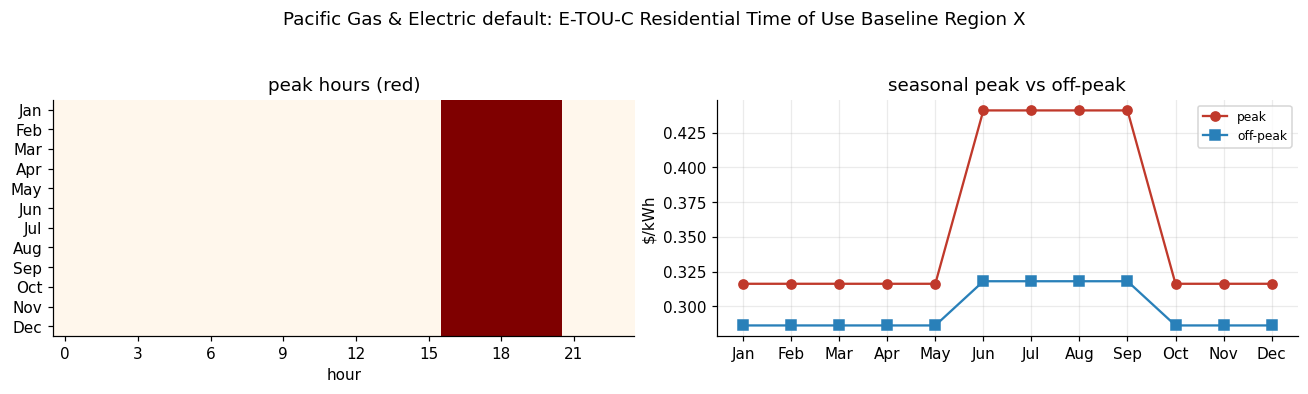

In [5]:
def plot_heatmap(t, ax):
    rec=_RAW.get(t['label'])
    if not rec or not t['is_tou']: ax.text(.5,.5,'flat rate (no peak window)',ha='center'); ax.set_axis_off(); return
    sched=np.array(rec['energyweekdayschedule']); mask=np.zeros((12,24),int)
    for m in range(12): mask[m]=(sched[m]==t['by_month'][m]['peak_period']).astype(int)
    ax.imshow(mask,aspect='auto',cmap='OrRd'); ax.set_yticks(range(12)); ax.set_yticklabels(MONTHS)
    ax.set_xticks(range(0,24,3)); ax.set_xlabel('hour'); ax.set_title('peak hours (red)'); ax.grid(False)
def plot_seasonal(t, ax):
    pk=[t['by_month'][m]['peak'][0]['rate'] for m in range(12)]
    op=[t['by_month'][m]['offpeak'][0]['rate'] for m in range(12)]
    ax.plot(MONTHS,pk,'-o',color='#c0392b',label='peak'); ax.plot(MONTHS,op,'-s',color='#2980b9',label='off-peak')
    ax.set_ylabel('$/kWh'); ax.legend(fontsize=8); ax.set_title('seasonal peak vs off-peak')

def show_for_zip(zipcode='94301'):
    e=RR.resolve(str(zipcode)).electricity; eid=e.utility_id
    if COV.decide(eid)!='urdb':
        print(f'ZIP {zipcode}: no URDB plans (uses a flat average) — see section 1 for the rate.'); return
    u=DB[str(eid)]; d=default(u)
    print(f"{u['utility']} — plans available (used default = {d['family']}):")
    for t in u['tariffs'].values():
        s=t['by_month'][6]
        star='  <-- default' if t['whywatt_default'] else ''
        print(f"   {t['family']:12} {t['plan_kind']:13} summer peak ${s['peak'][0]['rate']:.3f} / off ${s['offpeak'][0]['rate']:.3f}{star}")
    fig,ax=plt.subplots(1,2,figsize=(12,3.4)); plot_heatmap(d,ax[0]); plot_seasonal(d,ax[1])
    plt.suptitle(f"{u['utility']} default: {d['name'][:56]}", y=1.04); plt.tight_layout(); plt.show()
show_for_zip('94301')


In [6]:
interact(show_for_zip, zipcode=Text('94301', description='ZIP'));


interactive(children=(Text(value='94301', description='ZIP'), Output()), _dom_classes=('widget-interact',))

---
*Data built offline by `scripts/build_urdb.py`, `build_urdb_coverage.py`, `build_baseline_crosswalk.py`. Rebuild those, then re-run this notebook.*
